# 01 - sensing pipeline checks (SW-S*)
synthetic 4x4 frames, no hardware. just making sure the math holds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
# quick path hack so the repo modules import from notebooks/


In [2]:
#MD ## ambient subtraction (SW-S1)

In [3]:
from touch_sensing import TouchPanel, render_map, GRID
p = TouchPanel(threshold=10)
illum  = np.full((GRID,GRID), 50.0)
ambient= np.full((GRID,GRID), 8.0)
sig = p.signal(illum, ambient)
print(sig)
assert np.allclose(sig, 42.0)   # ok 50-8, green

[[42. 42. 42. 42.]
 [42. 42. 42. 42.]
 [42. 42. 42. 42.]
 [42. 42. 42. 42.]]


In [4]:
#MD ## baseline calibration (SW-S2)

In [5]:
frames = [(np.full((GRID,GRID), 50.0+k), np.full((GRID,GRID),8.0)) for k in range(20)]
base = p.calibrate(frames)
print("baseline mean", base.mean(), "noise sigma ~", p.noise.mean())
# almost forgot you have to calibrate before detecting lol

baseline mean 51.5 noise sigma ~ 5.766281297335398


In [6]:
#MD ## known finger pattern -> touch map (SW-S3)

. . X .
. X . .
. . . .
. . . .


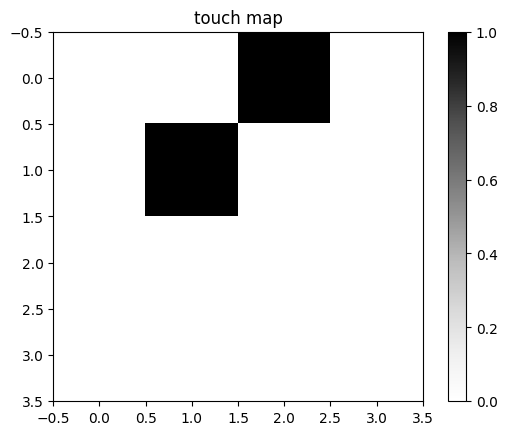

In [7]:
illum = np.full((GRID,GRID), base.mean()+8.0)   # untouched-ish
illum[0,2] = 120; illum[1,1] = 110              # two fingers
tmap = p.touch_map(illum, ambient)
print(render_map(tmap))
plt.imshow(tmap, cmap="Greys"); plt.title("touch map"); plt.colorbar(); plt.show()
exp = np.zeros((GRID,GRID),bool); exp[0,2]=exp[1,1]=True
assert np.array_equal(tmap, exp)   # matches, good

In [8]:
#MD ## above vs below threshold (SW-S4)

In [9]:
weak = np.full((GRID,GRID), base.mean()+8.0); weak[2,2]+=5     # tiny bump
strong = weak.copy(); strong[3,3]+=40
print("weak flagged:", p.touch_map(weak,ambient).any(), "  strong flagged:", p.touch_map(strong,ambient)[3,3])
# small change stays quiet, big one trips. fine

weak flagged: False   strong flagged: True


In [10]:
#MD ## guard rails (SW-S5, SW-S6)

In [11]:
import traceback
try:
    TouchPanel().touch_change(illum, ambient)
except RuntimeError as e:
    print("caught detect-before-calibrate:", e)
try:
    p.signal(np.zeros((3,3)), np.zeros((3,3)))
except ValueError as e:
    print("caught bad shape:", e)
# both raise like they should

caught detect-before-calibrate: calibrate() before detecting
caught bad shape: frame must be 4x4, got (3, 3)
